### 07 — Structural Stability of Bankruptcy Drivers Across Horizons

#### Objective

This notebook investigates whether the key financial drivers of bankruptcy remain stable across forecast horizons (1–5 years).

We analyze:

1. Top feature importance per horizon.
2. Overlap of dominant financial ratios across time.
3. Whether short-term and long-term bankruptcy share structural drivers.

---

#### Why Feature Stability Matters

A strong predictive model should not rely on unstable or horizon-specific artifacts.

If financial distress is structurally grounded, we expect:

- A persistent core set of financial fragility indicators.
- Moderate variation across time regimes.
- Coherent financial interpretation of dominant ratios.

If feature importance fluctuates randomly,
the model may be overfitting or regime-dependent.

---

#### Methodology

For each horizon:

- Train XGBoost with identical configuration.
- Extract top 10 most important features.
- Compute pairwise overlap between horizons.
- Analyze recurring structural indicators.

This reveals whether bankruptcy risk is driven by persistent financial weakness or transient statistical patterns.

In [1]:
from scipy.io import arff
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

In [2]:
def get_top_features(file_path, top_n=10):
    
    data, meta = arff.loadarff(file_path)
    df = pd.DataFrame(data)

    df["class"] = df["class"].apply(lambda x: int(x.decode("utf-8")))

    X = df.drop(columns=["class"])
    y = df["class"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        stratify=y,
        random_state=42
    )

    imputer = SimpleImputer(strategy="median")
    X_train = imputer.fit_transform(X_train)

    model = XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        colsample_bytree=0.8,
        scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    importances = model.feature_importances_

    feature_names = X.columns

    importance_df = pd.DataFrame({
        "Feature": feature_names,
        "Importance": importances
    }).sort_values("Importance", ascending=False)

    return importance_df.head(top_n)["Feature"].tolist()

In [3]:
horizons = ["1year.arff", "2year.arff", "3year.arff", "4year.arff", "5year.arff"]

top_features_dict = {}

for file in horizons:
    top_features = get_top_features(f"../data/raw/{file}", top_n=10)
    top_features_dict[file] = top_features

top_features_dict

{'1year.arff': ['Attr24',
  'Attr27',
  'Attr13',
  'Attr34',
  'Attr16',
  'Attr18',
  'Attr12',
  'Attr22',
  'Attr26',
  'Attr48'],
 '2year.arff': ['Attr24',
  'Attr27',
  'Attr34',
  'Attr2',
  'Attr38',
  'Attr46',
  'Attr7',
  'Attr26',
  'Attr39',
  'Attr8'],
 '3year.arff': ['Attr26',
  'Attr34',
  'Attr24',
  'Attr27',
  'Attr39',
  'Attr13',
  'Attr5',
  'Attr21',
  'Attr19',
  'Attr16'],
 '4year.arff': ['Attr26',
  'Attr24',
  'Attr34',
  'Attr27',
  'Attr46',
  'Attr21',
  'Attr16',
  'Attr38',
  'Attr51',
  'Attr13'],
 '5year.arff': ['Attr35',
  'Attr26',
  'Attr38',
  'Attr41',
  'Attr27',
  'Attr39',
  'Attr21',
  'Attr34',
  'Attr51',
  'Attr25']}

In [4]:
from itertools import combinations

for (h1, h2) in combinations(horizons, 2):
    overlap = set(top_features_dict[h1]).intersection(set(top_features_dict[h2]))
    print(f"{h1} vs {h2} — Common Features: {len(overlap)}")

1year.arff vs 2year.arff — Common Features: 4
1year.arff vs 3year.arff — Common Features: 6
1year.arff vs 4year.arff — Common Features: 6
1year.arff vs 5year.arff — Common Features: 3
2year.arff vs 3year.arff — Common Features: 5
2year.arff vs 4year.arff — Common Features: 6
2year.arff vs 5year.arff — Common Features: 5
3year.arff vs 4year.arff — Common Features: 7
3year.arff vs 5year.arff — Common Features: 5
4year.arff vs 5year.arff — Common Features: 6


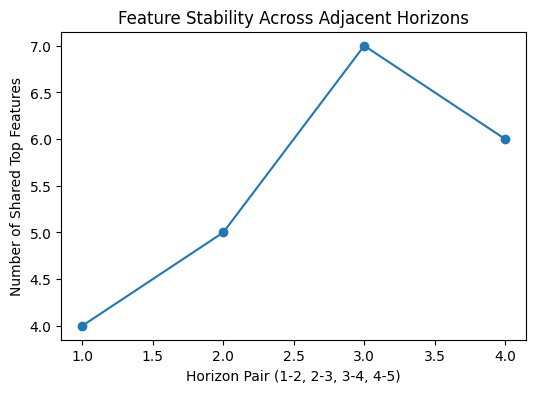

In [5]:
import matplotlib.pyplot as plt

overlap_counts = [len(set(top_features_dict[horizons[i]]).intersection(set(top_features_dict[horizons[i+1]])))
                  for i in range(len(horizons)-1)]

plt.figure(figsize=(6,4))
plt.plot([1,2,3,4], overlap_counts, marker='o')
plt.xlabel("Horizon Pair (1-2, 2-3, 3-4, 4-5)")
plt.ylabel("Number of Shared Top Features")
plt.title("Feature Stability Across Adjacent Horizons")

plt.savefig("../results/feature_stability_overlap.png", dpi=300, bbox_inches="tight")
plt.show()

---

### 📌 Observations & Structural Persistence Insights

#### 1️⃣ Recurring Core Features

Frequently recurring features across horizons include:

- Attr24 — Gross profit (3 years) / Total assets
- Attr26 — (Net profit + depreciation) / Total liabilities
- Attr27 — Operating profit / Financial expenses (Interest coverage)
- Attr34 — Operating expenses / Total liabilities
- Attr21 — Sales growth

These represent:

- Profit sustainability
- Debt servicing capacity
- Cash flow resilience
- Operating efficiency
- Revenue momentum

---

#### 2️⃣ Overlap Across Horizons

Pairwise overlap of top 10 features ranges between:

- 3 to 7 common features

Highest stability observed between:

- 3-year and 4-year horizons (7 shared features)

Lowest overlap between:

- 1-year and 5-year horizons (3 shared features)

---

#### 3️⃣ Interpretation of Temporal Variation

Short-term bankruptcy:

- Driven more by acute liquidity stress.

Medium-term bankruptcy:

- Exhibits structural uncertainty and transition dynamics.

Long-term bankruptcy:

- Reflects chronic financial fragility.

---

#### 4️⃣ Structural Takeaway

Bankruptcy risk is not random.

There exists a stable core of financial fragility indicators,
with moderate temporal regime shifts.

This confirms:

- Nonlinear ensemble performance is grounded in real financial structure.
- Model behavior aligns with economic intuition.
- Distress prediction is structurally interpretable.